# Dependencies

In [3]:
"""Fake News Detection.ipynb

Original file is located at

    https://colab.research.google.com/drive/1sugGivohanlPgnnTa1x5UL0L6VZfeqBz
"""
import xgboost as xgb

from wordcloud import WordCloud

import pickle

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

import seaborn as sns

from string import punctuation

#nltk
import nltk

from nltk.corpus import stopwords, wordnet, opinion_lexicon

from nltk.tokenize import word_tokenize, punkt, sent_tokenize

from nltk.sentiment.vader import SentimentIntensityAnalyzer

from nltk.stem import WordNetLemmatizer

#sklearn
from sklearn.experimental import enable_halving_search_cv

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, HalvingGridSearchCV

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.neighbors import KNeighborsClassifier

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_selection import SelectFromModel

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.svm import SVC

from sklearn.experimental import enable_halving_search_cv 

from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.base import BaseEstimator, ClassifierMixin

/opt/conda/lib/python3.10/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


In [3]:
# Load NLTK's lexicons in order to later calculate every word frequency by these lexicons
nltk.download('wordnet')

!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

nltk.download('vader_lexicon')

nltk.download('punkt')

nltk.download('stopwords')

nltk.download('opinion_lexicon')

stop_words = set(stopwords.words('english'))

positive_words = set(opinion_lexicon.positive())

negative_words = set(opinion_lexicon.negative())

print("Positive words:", list(positive_words)[:10])

print("Negative words:", list(negative_words)[:10])

print("Stop words:", list(stop_words)[:10])

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/co

# initial filtering

In [3]:
# Load the dataset from kaggle
WELFake_Dataset = pd.read_csv("/kaggle/input/fake-news-classification/WELFake_Dataset.csv")
WELFake_Dataset.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
# Title / Text separation. First we decided to work only on the texts because there aren't a lot of samples with both text and title

titles_df= WELFake_Dataset.copy()[['title','label']]

texts_df = WELFake_Dataset.copy()[['text', 'label']]

print("initial shape titles: ",titles_df.shape)

print("initial shape texts: ",texts_df.shape)

titles_df.dropna(inplace=True)

texts_df.dropna(inplace=True)

titles_df.drop_duplicates(inplace=True)

texts_df.drop_duplicates(inplace=True)

print("final shape titles: ",titles_df.shape)

print("final shape texts: ",texts_df.shape)

### Throughout the project we use the same value of random_state = 42 to recreate our results and to gain determinism

In [ ]:
'''# Train / Test separation

# 0 - fake , 1 - real

texts_X_train, texts_X_test, texts_y_train, texts_y_test = train_test_split(texts_df[['text']], texts_df[['label']], test_size=0.2, random_state=42)

titles_X_train, titles_X_test, titles_y_train, titles_y_test = train_test_split(titles_df[['title']], titles_df[['label']], test_size=0.2, random_state=42)'''

# Feature Extraction

### Stop words, Sentiment Analysis, Uppercase word frequency, Punctuation frequency, MFD features, TF-IDF

In [3]:
#stop-words removal & frequency. for each text calculate as a feature the percentage of stopwords in the text.
#also remove all stopwords to create filtered_text feature
def stopword_features(text):
    words = np.array(word_tokenize(text), dtype=str)
    if len(words)==0:
        return 0,''
    words_lower = np.char.lower(words)
    filtered_text = ' '.join(words[~np.isin(words_lower, list(stop_words))])
    stopword_count = np.sum(np.isin(words_lower, list(stop_words)))
    stopword_frequency = stopword_count / len(words)
    return stopword_frequency, filtered_text

#sentiment Analysis - for each text calculate polarity scores (expanded explanation in dry report)
sid = SentimentIntensityAnalyzer()
def analyze_sentiment(text):
    return sid.polarity_scores(text)
    
#uppercase word frequency. for each text calculate as a feature the percentage of words in which every letter is uppercased in the text.
def uppercase_word_frequency(text):
    words = np.array(word_tokenize(text), dtype=str)
    if len(words) == 0:
        return 0
    uppercase_words = np.array([w for w in words if w.isupper()])
    return len(uppercase_words) / len(words)

#punctuation frequency. for each text calculate as a feature the percentage of punctuation in the text
def punctuation_frequency(text):
    words = np.array(word_tokenize(text), dtype=str)
    if len(words) == 0:
        return 0
    punctuations = np.array([w for w in words if w in list(punctuation)])
    return len(punctuations) / len(words)
    
#Moral Foundation Dictionary. generate the dictionary from the MFD file with categories as keys and words in each category as values.
MFD_path = '/kaggle/input/mfd2-0/mfd2.0.dic'
dic_content = {}
dic_category = {}
with open(MFD_path, 'r', encoding='utf-8') as file:
    for line in file:
        if line.startswith('%'):
            continue
        tokens=word_tokenize(line)
        if tokens[0].isnumeric():
            dic_category[int(tokens[0])]=tokens[-1]
            dic_content[tokens[-1]]=[]
        else:
            term, id = tokens[0], tokens[-1]
            dic_content[dic_category[int(id)]].append(term)

#for each category from MFD generate feature which holdes the percentage of words from this category in the text.
def MFD_features(text):
  words = np.array(word_tokenize(text), dtype=str)
  words = np.char.lower(words)
  frequencies = {}
  for category, terms in dic_content.items():
    words_category = np.array([w for w in words if w in terms])
    category_count = len(words_category)
    if len(words) == 0:
      category_frequency = 0
    else:
      category_frequency = category_count / len(words)
    frequencies[category] = category_frequency
  return frequencies

#lemmatization for TF-IDF. for each filtered text create feature Lemmatized_text which hold the lemmatization of the filtered_text feature.
def Lemmatize(text):
  lemma = WordNetLemmatizer()
  words= word_tokenize(str(text))
  lemmatized_words = [lemma.lemmatize(word) for word in list(words)]
  return ' '.join(lemmatized_words)

In [ ]:
"""# Apply the preprocessing functions to the 'text' column on Train set

texts_X_train['stopword_count'], texts_X_train['filtered_text'] = zip(*texts_X_train['text'].apply(stopword_features))

print("before filtering: ", texts_X_train.shape)

texts_X_train=texts_X_train[texts_X_train['filtered_text']!='']

print("after filtering: ", texts_X_train.shape)

print(texts_X_train.head())

sentiment_df = texts_X_train['text'].apply(analyze_sentiment).apply(pd.Series)

texts_X_train = pd.concat([texts_X_train, sentiment_df], axis=1)

texts_X_train.head()

texts_X_train['uppercase_word_count'] = texts_X_train['filtered_text'].apply(uppercase_word_frequency)

texts_X_train.head()

texts_X_train['punctuation_count'] = texts_X_train['filtered_text'].apply(punctuation_frequency)

texts_X_train.head()

MFD_df = texts_X_train['filtered_text'].apply(MFD_features).apply(pd.Series)

texts_X_train = pd.concat([texts_X_train, MFD_df], axis=1)

print(texts_X_train)

texts_X_train['lemmatized_text'] = texts_X_train['filtered_text'].apply(Lemmatize)

texts_X_train.dropna(inplace=True)

tfidf_vectorizer = TfidfVectorizer(use_idf=True,min_df=0.05)

# Fit the vectorizer to the train data ONLY

fitted_vectorizer = tfidf_vectorizer.fit(list(texts_X_train['lemmatized_text']))

tfidf_matrix = fitted_vectorizer.transform(list(texts_X_train['lemmatized_text']))

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=fitted_vectorizer.get_feature_names_out())

texts_X_train = pd.concat([texts_X_train, tfidf_df], axis=1)

texts_X_train.dropna(inplace=True)

print(texts_X_train.head())

print(fitted_vectorizer.get_feature_names_out())

print(tfidf_matrix.shape)"""

# Save Train

In [ ]:
"""# train texts features

save_train=texts_X_train.drop(['text', 'filtered_text', 'lemmatized_text'],axis=1)

save_train['label']=texts_y_train

save_train.to_csv('/kaggle/working/texts_train_features.csv', index=False) #  dont save the index colunm as feature

# train texts

save_train=texts_X_train[['text', 'filtered_text', 'lemmatized_text']]

save_train.to_csv('/kaggle/working/texts_train.csv', index=False) # dont save the index colunm as feature"""

# Test Data Processing

In [ ]:
"""# Apply the same preprocessing steps to the text colunm in test data

texts_X_test['stopword_count'], texts_X_test['filtered_text'] = zip(*texts_X_test['text'].apply(stopword_features))
texts_X_test=texts_X_test[texts_X_test['filtered_text']!='']

test_sentiment_df = texts_X_test['text'].apply(analyze_sentiment).apply(pd.Series)

texts_X_test = pd.concat([texts_X_test, test_sentiment_df], axis=1)

texts_X_test['uppercase_word_count'] = texts_X_test['filtered_text'].apply(uppercase_word_frequency)

texts_X_test['punctuation_count'] = texts_X_test['filtered_text'].apply(punctuation_frequency)

test_MFD_df = texts_X_test['filtered_text'].apply(MFD_features).apply(pd.Series)

texts_X_test = pd.concat([texts_X_test, test_MFD_df], axis=1)

texts_X_test['lemmatized_text'] = texts_X_test['filtered_text'].apply(Lemmatize)

texts_X_test.dropna(inplace=True)

# tf idf ONLY for a single vector each time

tfidf_matrix = fitted_vectorizer.transform(list(texts_X_test['lemmatized_text']))

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=fitted_vectorizer.get_feature_names_out())

texts_X_test = pd.concat([texts_X_test, tfidf_df], axis=1)

texts_X_test.dropna(inplace=True)

texts_X_test.head()

print(tfidf_matrix.shape)"""

# Save Test

In [ ]:
"""# test texts features

save_test=texts_X_test.drop(['text', 'filtered_text', 'lemmatized_text'],axis=1)

save_test['label']=texts_y_test

save_test.to_csv('/kaggle/working/texts_test_features.csv', index=False)  # dont save the index colunm as feature

# test texts

save_test=texts_X_test[['text', 'filtered_text', 'lemmatized_text']]

save_test.to_csv('/kaggle/working/texts_test.csv', index=False)  # dont save the index colunm as feature"""

# Load Data

In [4]:
# Load text processed dataset

#the texts of the train set
texts_train = pd.read_csv("/kaggle/input/train-test-datasets/texts_train.csv")

#only the float features of the train data
texts_train_features = pd.read_csv("/kaggle/input/train-test-datasets/texts_train_features.csv")

texts_X_train, texts_y_train = texts_train_features.drop('label', axis=1), texts_train_features['label'] 
#create validation set from tain set
texts_X_train, texts_X_val, texts_y_train, texts_y_val, texts_train, texts_val = train_test_split(texts_X_train, texts_y_train, texts_train, test_size=0.2, random_state=42)

texts_test_features = pd.read_csv("/kaggle/input/train-test-datasets/texts_test_features.csv")
#test set- same steps
texts_test = pd.read_csv("/kaggle/input/train-test-datasets/texts_test.csv")

texts_X_test, texts_y_test = texts_test_features.drop('label', axis=1), texts_test_features['label'] 

# Data Visualization

In [ ]:
# Word Cloud generation for each label
texts_train['label'] = texts_y_train

# real news wordclouds
text_label1 = texts_train[texts_train['label'] == 1]['lemmatized_text']

wordcloud_label1 = WordCloud(width=800, height=400, background_color='white').generate(str(text_label1))

# fake news wordclouds
text_label0 = texts_train[texts_train['label'] == 0]['lemmatized_text']

wordcloud_label0 = WordCloud(width=800, height=400, background_color='white').generate(str(text_label0))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)

plt.imshow(wordcloud_label1, interpolation='bilinear')

plt.title('Word Cloud for real news')

plt.axis('off')

plt.subplot(1, 2, 2)

plt.imshow(wordcloud_label0, interpolation='bilinear')

plt.title('Word Cloud for fake news')

plt.axis('off')

plt.tight_layout()

plt.show()

texts_train.drop(columns=['label'],inplace=True)

# Helpers

### documentation for the following functions can be found in file "Helpers Docs.md"

In [1]:
def save_state(state, path='state.txt'):
    with open(path,mode='wb') as file:
        pickle.dump(state,file)

def load_state(path='state.txt'):
    state = None
    with open(path,mode='rb') as file:
        state = pickle.load(file)
    return state

def visualize_importances(importances):
    features = texts_X_train.columns
    features_importances = list(zip(features, importances))
    features_importances = [(x,y) for x,y in features_importances if y>0.005]
    features, feature_importances = zip(*features_importances)
    plt.figure(figsize=(10, 6))
    plt.barh(list(features), list(feature_importances))
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('Feature Importance')
    plt.show()

def visualize_confusion(cm):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')    
    plt.title('Confusion Matrix')
    plt.show()

def visualize_correlation(X, y, sampled_columns=None, visualize=True, correlationMatrix=None):
    full = pd.concat([X, y], axis=1)
    if correlationMatrix is None:
        correlationMatrix = full.corr(method='pearson')

    if visualize:
        plt.figure(figsize=(20,12))
        if sampled_columns is None:
            sns.heatmap(correlationMatrix)
        else:
            sampled_columns = list(sampled_columns)
            sampled_columns.append('label')
            sns.heatmap(correlationMatrix.loc[sampled_columns, sampled_columns])
            
    return correlationMatrix

def visualize_clf(clf, X, Y, title, xlabel, ylabel, marker_size=50, grid_length=300, linewidths=None):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    # For internal use here, make sure labels are 0 and 1
    Y = np.ravel(Y).astype(int)
    labels = set(Y)
    assert len(labels) == 2, "Can only visualize two unique labels"
    if labels == set([-1,1]):
      Y = (Y + 1) // 2
      labels = set(Y)
    assert labels == set([0,1]), "Could not handle given labels"
    plt.figure(figsize=(8, 8))

    # Parameters
    n_classes = 2
    markers = ["D", "o"]
    palette = sns.color_palette("hls", 2)
    custom_cmap = ListedColormap(palette.as_hex())
    x_delta = np.abs(X[:, 0].max() - X[:, 0].min()) * 0.1
    y_delta = np.abs(X[:, 1].max() - X[:, 1].min()) * 0.1
    x_min, x_max = X[:, 0].min() - x_delta, X[:, 0].max() + x_delta
    y_min, y_max = X[:, 1].min() - y_delta, X[:, 1].max() + y_delta
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_length), np.linspace(y_min, y_max, grid_length))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.35)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.75)
    
    # Plot the training points
    for i, color, marker in zip(labels, palette, markers):
        idx = np.where(Y == i)
        plt.scatter(X[idx,0], X[idx,1], color=color, marker=marker, edgecolor='white', s=marker_size,
                    linewidths=linewidths)
    plt.title(title, fontsize=20)
    plt.axis("tight")
    plt.show()

# **Knn**


In [ ]:
# try modeling with knn with n_neighbors = 5

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(texts_X_train, texts_y_train)

y_pred = knn.predict(texts_X_train)

# calculate accuracy score on predictions related to true classifications
accuracy = accuracy_score(texts_y_train, y_pred)

print(f'Train Accuracy: {accuracy}')

y_pred = knn.predict(texts_X_val)

accuracy = accuracy_score(texts_y_val, y_pred)

print(f'Validation Accuracy: {accuracy}')

## Find Best k

In [15]:
#change the test_list to recreate results
neighbors_list = list(range(20, 1000, 50))
neighbors_list_expanded = list(range(20, 1000, 50))+list(range(1000, 1201, 20))
test_list=neighbors_list

In [16]:
# experiment: Tune hyperParameter n_neighbors by cross validating- choose list as you wish above

train_scores_mean = []

test_scores_mean = []
# for each k in test_list create a model, cross validate with 5 folds meaning- split the train data to 5 folds and for each fold- 
#train on the other 4 folds and validate on the current fold. in the end calculate and save the mean train & validation accuracies from cross
# validating on this k
for k in test_list:

    knn = KNeighborsClassifier(n_neighbors=k)

    cv_results = cross_validate(knn, texts_X_train, texts_y_train, cv=5, return_train_score=True)

    train_scores_mean.append(np.mean(cv_results['train_score']))

    test_scores_mean.append(np.mean(cv_results['test_score']))

# extract best k (highest mean validation accuracy) and present its performance in the cross validation
max_idx = np.argmax(test_scores_mean)

best_k = test_list[max_idx]

average_train_accuracy = train_scores_mean[max_idx]

average_validation_accuracy = test_scores_mean[max_idx]

print("Best value for k:", best_k)

print("Average training accuracy for the best k value:", average_train_accuracy)

print("Average validation accuracy for the best k value:", average_validation_accuracy)


Best value for k: 920
Average training accuracy for the best k value: 0.5795861304388689
Average validation accuracy for the best k value: 0.575505941668362


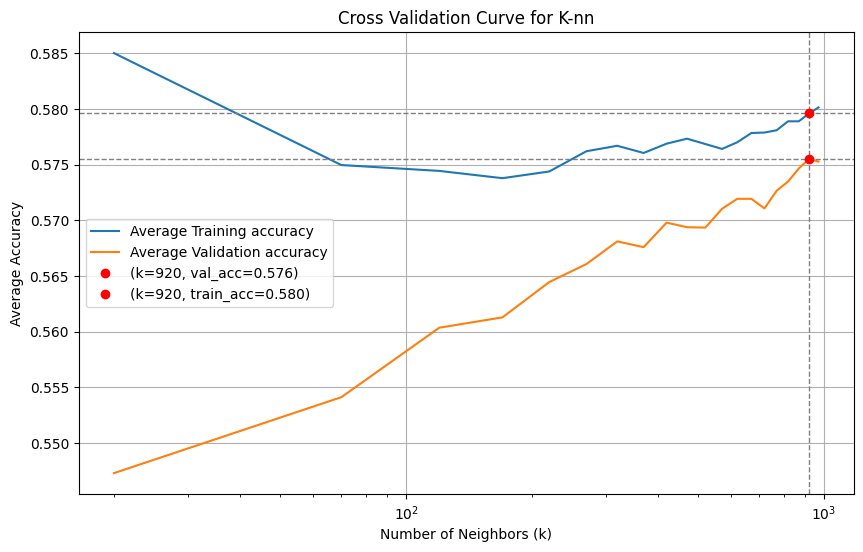

In [17]:
#plot the average accuracy graph
plt.figure(figsize=(10, 6))

plt.semilogx(test_list, train_scores_mean, label='Average Training accuracy')

plt.semilogx(test_list, test_scores_mean, label='Average Validation accuracy')

plt.axvline(best_k, color='gray', linestyle='--', linewidth=1)
plt.axhline(average_validation_accuracy, color='gray', linestyle='--', linewidth=1)

plt.plot(best_k, average_validation_accuracy, 'o', color='red', label=f'(k={best_k}, val_acc={average_validation_accuracy:.3f})')

plt.axhline(average_train_accuracy, color='gray', linestyle='--', linewidth=1)

plt.plot(best_k, average_train_accuracy, 'o', color='red', label=f'(k={best_k}, train_acc={average_train_accuracy:.3f})')

plt.title('Cross Validation Curve for K-nn')

plt.xlabel('Number of Neighbors (k)')

plt.ylabel('Average Accuracy')

plt.legend()

plt.grid(True)

plt.show()

## Performance with best k

In [13]:
knn_best_k = KNeighborsClassifier(n_neighbors=best_k)

knn_best_k.fit(texts_X_train, texts_y_train)

train_accuracy = knn_best_k.score(texts_X_train, texts_y_train)

print("Train Accuracy:", train_accuracy)

val_accuracy = knn_best_k.score(texts_X_val, texts_y_val)

print("Validation Accuracy:", val_accuracy)

Train Accuracy: 0.5794656383418262
Validation Accuracy: 0.5703662902781603


## Visualize best k Decision regions with 2 features

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


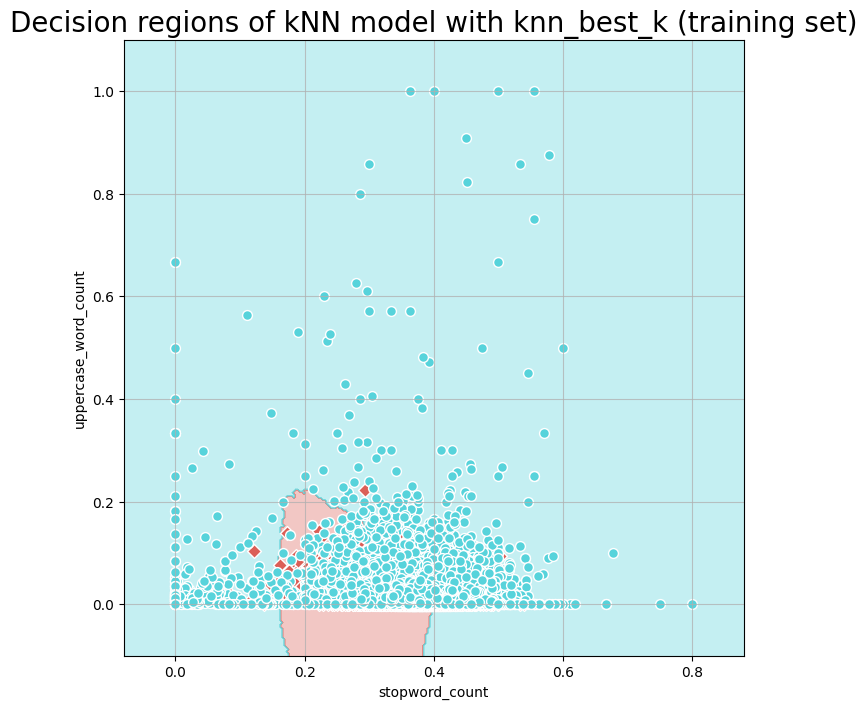

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


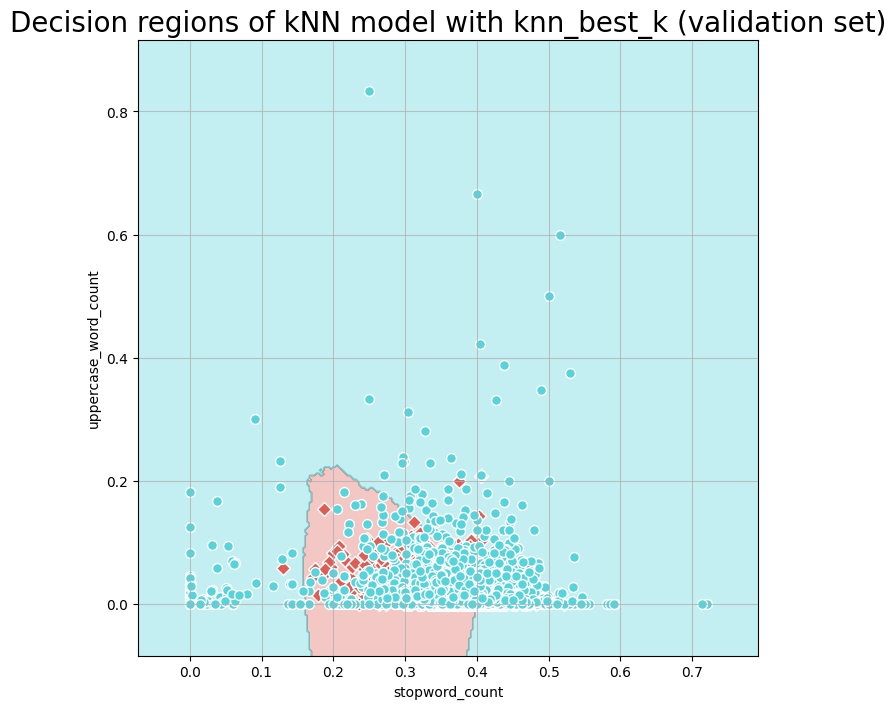

Train Accuracy: 0.7110935132901804
Validation Accuracy: 0.7058661525750481


In [14]:
# use visualize_clf to visualize the decsion regions of 2 interesting features (2D space)
knn_best_k = KNeighborsClassifier(n_neighbors=best_k)

knn_best_k.fit(texts_X_train[["stopword_count", "uppercase_word_count"]], texts_y_train)

visualize_clf(knn_best_k,  texts_X_train[["stopword_count", "uppercase_word_count"]], texts_y_train, "Decision regions of kNN model with knn_best_k (training set)", "stopword_count", "uppercase_word_count")

visualize_clf(knn_best_k,  texts_X_val[["stopword_count", "uppercase_word_count"]], texts_y_val, "Decision regions of kNN model with knn_best_k (validation set)", "stopword_count", "uppercase_word_count")

train_accuracy = knn_best_k.score(texts_X_train[["stopword_count", "uppercase_word_count"]], texts_y_train)

print("Train Accuracy:", train_accuracy)

val_accuracy = knn_best_k.score(texts_X_val[["stopword_count", "uppercase_word_count"]], texts_y_val)

print("Validation Accuracy:", val_accuracy)

# ID3

### With max_depth of 5

Training Accuracy: 0.7366753890648671


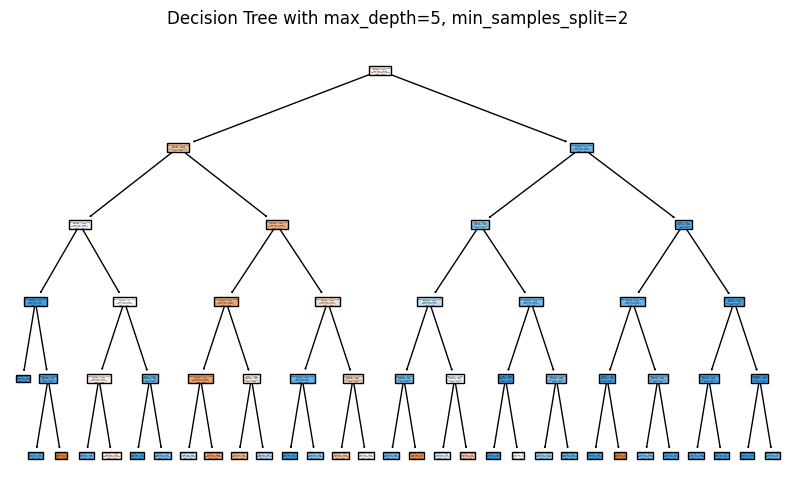

Validation Accuracy: 0.7298264940787662


In [18]:
# try modeling with decsion tree with max_depth = 5

tree_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5)

tree_classifier.fit(texts_X_train, texts_y_train)

# directly score on train set without returning y_pred
training_accuracy = tree_classifier.score(texts_X_train, texts_y_train)

print("Training Accuracy:", training_accuracy)

plt.figure(figsize=(10, 6))

plot_tree(tree_classifier, filled=True, feature_names=texts_X_train.columns, class_names=['fake', 'real'])

plt.title("Decision Tree with max_depth=5, min_samples_split=2")

plt.show()

val_accuracy = tree_classifier.score(texts_X_val, texts_y_val)

print("Validation Accuracy:", val_accuracy)

## Tune Hyperparameters min_samples_leaf & max_depth

In [19]:
# experiment: hyperparameters tuning. check if made a difference in the results
min_samples_leaf_range = list(range(1, 30, 2))

max_depth_range = list(range(5,16))

param_grid = {'min_samples_leaf': min_samples_leaf_range, 'max_depth': max_depth_range}

dt_classifier = DecisionTreeClassifier(criterion='entropy')
# found a different, simpler method for cross validation than the one used in Knn and used it. Though does the same trick
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
                         'min_samples_leaf': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19,
                                              21, 23, 25, 27, 29]},
             return_train_score=True)

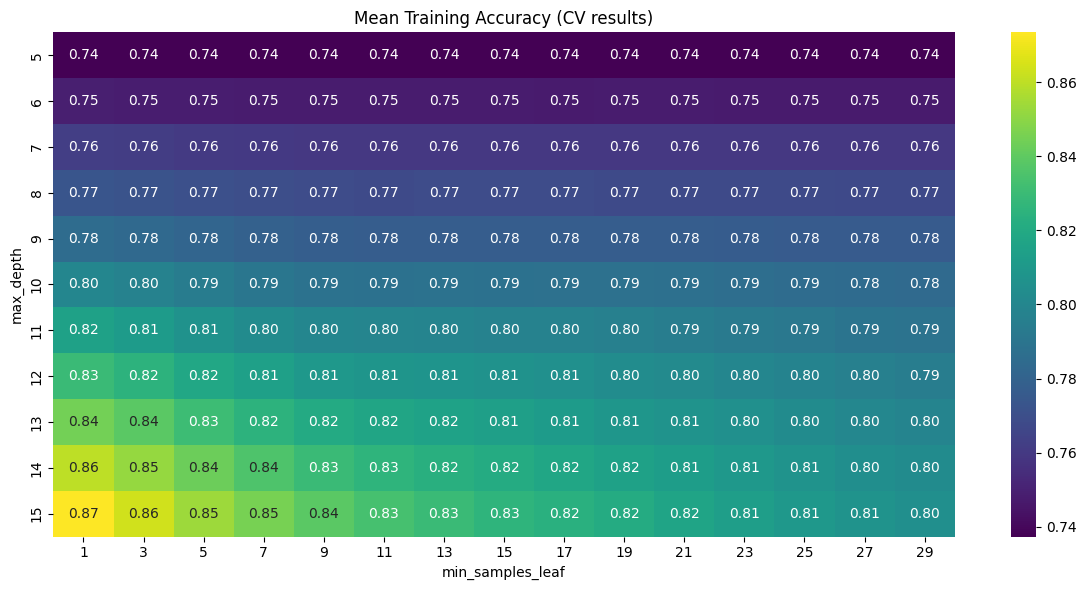

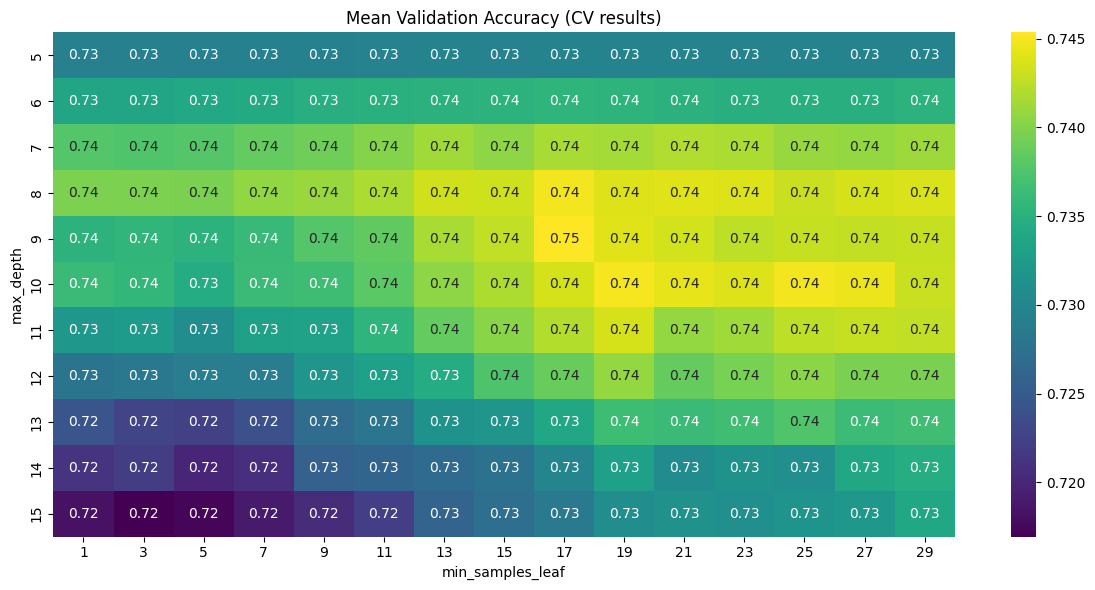

Best parameters found: {'max_depth': 9, 'min_samples_leaf': 17}


In [21]:
# visualize heatmaps of results in the cross validation. 
# For each couple of hyperparameters values, the according cell in the heatmap matrix is the train/validation accuracy.

ID3_tree = grid_search.best_estimator_

results = grid_search.cv_results_

mean_train_scores = results['mean_train_score'].reshape(len(max_depth_range), len(min_samples_leaf_range))

mean_validation_scores = results['mean_test_score'].reshape(len(max_depth_range), len(min_samples_leaf_range))

plt.figure(figsize=(12, 6))

sns.heatmap(mean_train_scores, cmap="viridis", annot=True, fmt=".2f", xticklabels=min_samples_leaf_range, yticklabels=max_depth_range)

plt.title('Mean Training Accuracy (CV results)')

plt.xlabel('min_samples_leaf')

plt.ylabel('max_depth')

plt.tight_layout()

plt.show()

plt.figure(figsize=(12, 6))

sns.heatmap(mean_validation_scores, cmap="viridis", annot=True, fmt=".2f", xticklabels=min_samples_leaf_range, yticklabels=max_depth_range)

plt.title('Mean Validation Accuracy (CV results)')

plt.xlabel('min_samples_leaf')

plt.ylabel('max_depth')

plt.tight_layout()

plt.show()

print("Best parameters found:", grid_search.best_params_)

## Decision Tree with optimal parameters

Train Accuracy: 0.7727585731992839


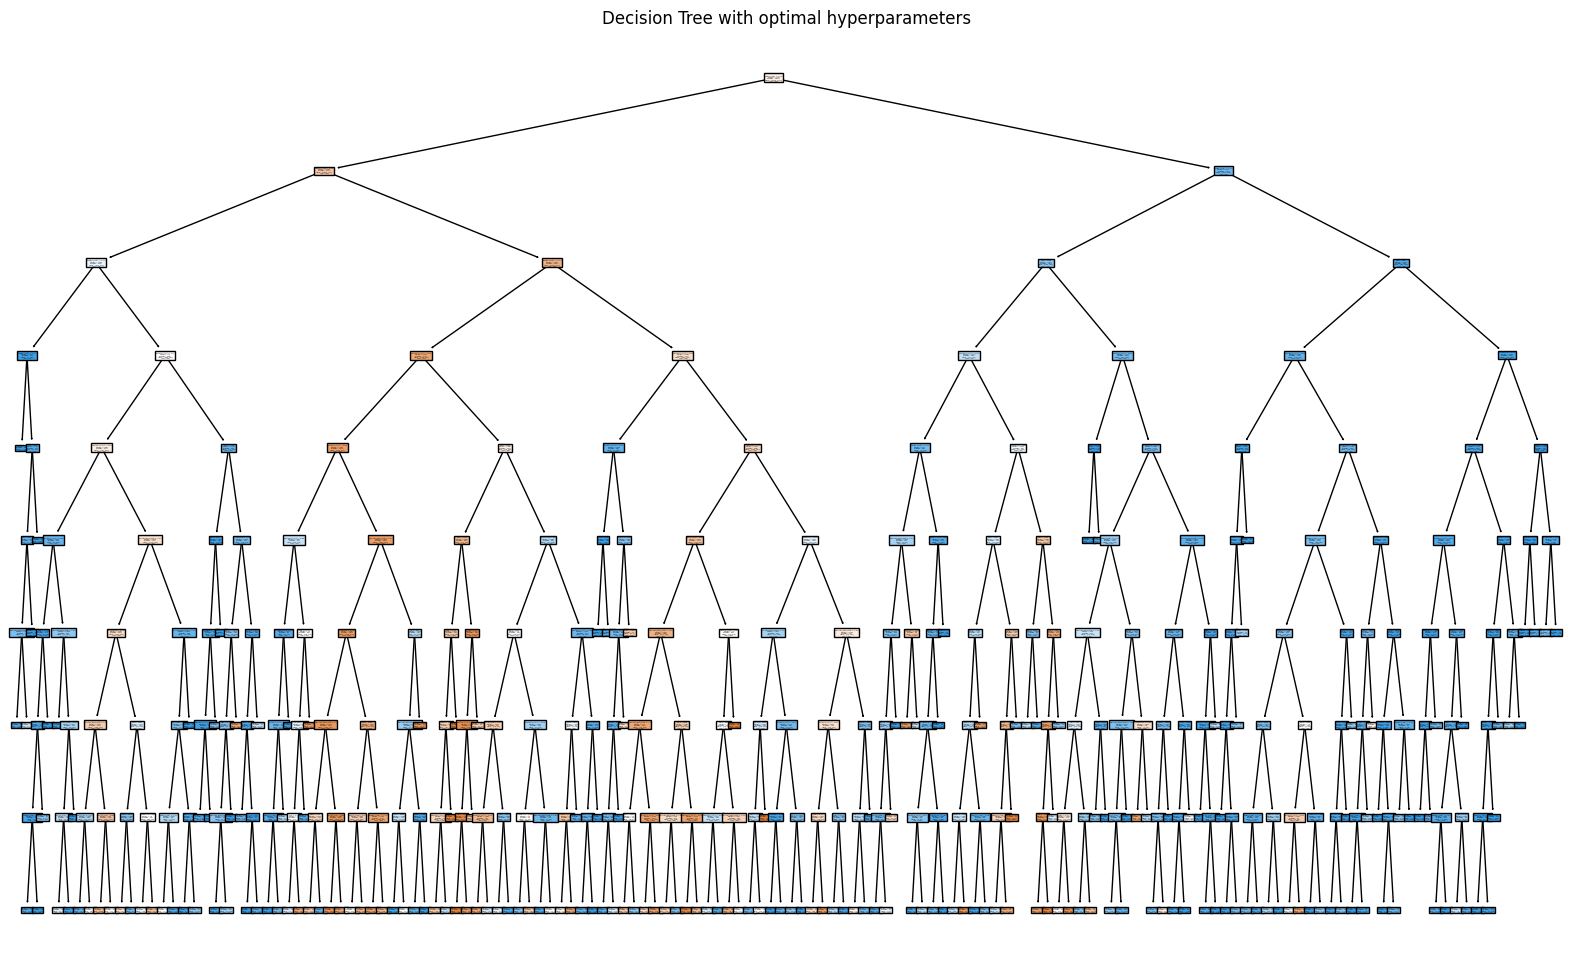

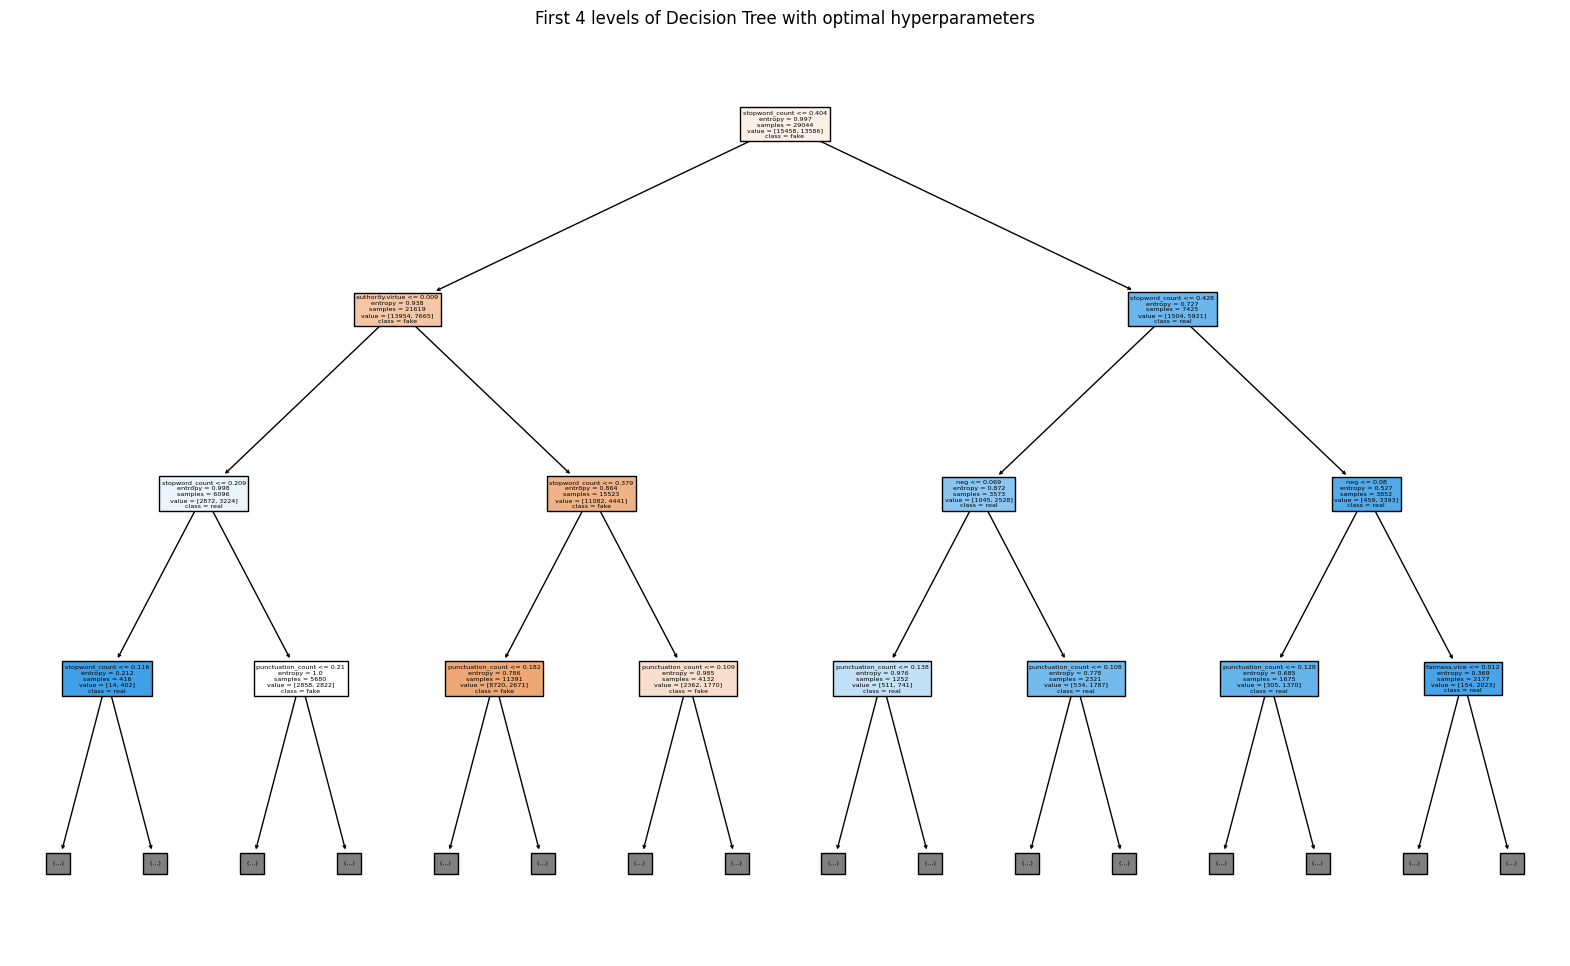

features used in first 4 levels of the tree ordered:  ['stopword_count', 'authority.virtue', 'neg', 'punctuation_count', 'fairness.vice']
Validation Accuracy: 0.7298264940787662


In [22]:
# Plot tree with optimal parameters structure and then zoom in on the first 4 levels to check what are the features chosen there.
max_depth = grid_search.best_params_['max_depth']

min_samples_leaf = grid_search.best_params_['min_samples_leaf']

tree_opt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, min_samples_leaf = min_samples_leaf)

tree_opt_classifier.fit(texts_X_train, texts_y_train)

train_accuracy = tree_opt_classifier.score(texts_X_train, texts_y_train)

print("Train Accuracy:", train_accuracy)

plt.figure(figsize=(20, 12))

plot_tree(tree_opt_classifier, filled=True, feature_names= texts_X_train.columns, class_names=['fake', 'real'])

plt.title("Decision Tree with optimal hyperparameters")

plt.show()

plt.figure(figsize=(20, 12))

plot_tree(tree_opt_classifier, filled=True, feature_names= texts_X_train.columns, class_names=['fake', 'real'],max_depth=3)

plt.title("First 4 levels of Decision Tree with optimal hyperparameters")

plt.show()

#after running got these features in 4 first levels
firstlevels=['stopword_count','authority.virtue','neg','punctuation_count','fairness.vice']

print('features used in first 4 levels of the tree ordered: ',firstlevels)

val_accuracy = tree_classifier.score(texts_X_val, texts_y_val)

print("Validation Accuracy:", val_accuracy)

# Soft SVM

## with RBF kernel

In [ ]:
# try modeling with RBF kernel, before tuning.
svm_model = SVC(kernel='rbf', C=1)

svm_model.fit(texts_X_train, texts_y_train)

train_acc = svm_model.score(texts_X_train, texts_y_train)

val_acc = svm_model.score(texts_X_val, texts_y_val)

print("Train accuracy:", train_acc)

print("Validation accuracy:", val_acc)

## Tune C and gamma

In [ ]:
# experiment: hyperParameters tuning

C_range = [0.5,1,1.5,5,10,20,50,100]

gamma_range = [1e-3,5e-3,0.01,0.05,0.1,0.5]

param_grid = {'C': C_range, 'gamma': gamma_range}

svm_model = SVC(kernel='rbf')
#from now on changed method for tuning due to time complexity. expanded explanation in dry report
grid_search = HalvingGridSearchCV(estimator=svm_model, param_grid=param_grid, max_resources=texts_X_train.shape[0]//2, return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

In [ ]:
results = grid_search.cv_results_

print("Best parameters found:", grid_search.best_params_)

print('Mean Train Score: ', results['mean_train_score'][grid_search.best_index_])

print('Mean Vaidation Score: ', results['mean_test_score'][grid_search.best_index_])

## Train with best C, gamma

In [ ]:
# check if tuning made any difference in accuracy. grid_search.score will check the performance on the best estimator it found in tuning
train_acc = grid_search.score(texts_X_train, texts_y_train)

val_acc = grid_search.score(texts_X_val, texts_y_val)

print("Train accuracy:", train_acc)

print("Validation accuracy:", val_acc)

## with Polynomial kernel

In [ ]:
# try modeling with Polynomial kernel, before tuning.
svm_model = SVC(kernel='poly', C=1)

svm_model.fit(texts_X_train, texts_y_train)

train_acc = svm_model.score(texts_X_train, texts_y_train)

val_acc = svm_model.score(texts_X_val, texts_y_val)

print("Train accuracy:", train_acc)

print("Validation accuracy:", val_acc)

## Tune C and gamma

In [ ]:
# experiment: tuning hyperparameters

C_range = [0.5,1,1.5,5,10,20,50,100]

gamma_range = [1e-3,5e-3,0.01,0.05,0.1,0.5]

param_grid = {'C': C_range, 'gamma': gamma_range}

svm_model = SVC(kernel='poly')

grid_search = HalvingGridSearchCV(estimator=svm_model, param_grid=param_grid, max_resources=texts_X_train.shape[0]//2, return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

results = grid_search.cv_results_

print("Best value for C, gamma:", grid_search.best_params_)

print("Average training accuracy for the best C, gamma values:", results['mean_train_score'][grid_search.best_index_])

print("Average validation accuracy for the best C, gamma values:", results['mean_test_score'][grid_search.best_index_])

## Train with best C, gamma

In [ ]:
# check if tuning made any difference in accuracy. grid_search.score will check the performance on the best estimator it found in tuning

train_acc = grid_search.score(texts_X_train, texts_y_train)

val_acc = grid_search.score(texts_X_val, texts_y_val)

print("Train accuracy: ", train_acc)

print("Validation accuracy: ", val_acc)

## with Linear kernel

In [ ]:
# try modeling with Linear kernel, before tuning.

svm_model = SVC(kernel='linear', C=1)

svm_model.fit(texts_X_train, texts_y_train)

train_acc = svm_model.score(texts_X_train, texts_y_train)

val_acc = svm_model.score(texts_X_val, texts_y_val)

print("Train accuracy:", train_acc)

print("Validation accuracy:", val_acc)

svm_model.coef_

print(svm_model.coef_.reshape(865).shape)

print(svm_model.feature_names_in_.reshape(865).shape)

# print weights of svm and their correspoding features in decsending order

for x,y in reversed(sorted(zip(svm_model.coef_.reshape(865),svm_model.feature_names_in_.reshape(865)), key=lambda a:np.abs(a[0]))):

    print(x,y)

## Tune C

In [ ]:
# experiment: tuning hyperparameter C

C_range = list(np.arange(0.1, 1.5, 0.01))+list(np.arange(1.5, 15.5, 0.5))+list(range(15, 50, 5))

param_grid = {'C': C_range}

svm_model = SVC(kernel='linear')

grid_search = HalvingGridSearchCV(estimator=svm_model, param_grid=param_grid, max_resources=texts_X_train.shape[0]//2, return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

results = grid_search.cv_results_

print("Best value for C:", grid_search.best_params_)

print("Average training accuracy for the best C value:", results['mean_train_score'][grid_search.best_index_])

print("Average validation accuracy for the best C value:", results['mean_test_score'][grid_search.best_index_])


## Train with best C

In [ ]:
# check if tuning made any difference in accuracy. grid_search.score will check the performance on the best estimator it found in tuning

train_acc = grid_search.score(texts_X_train, texts_y_train)

val_acc = grid_search.score(texts_X_val, texts_y_val)

print("Train accuracy: ", train_acc)

print("Validation accuracy: ", val_acc)

svm_model = grid_search.best_estimator_

print(svm_model.coef_.reshape(865).shape)

print(svm_model.feature_names_in_.reshape(865).shape)

# save for future use in feature selection and print weights of svm and their correspoding features in decsending order

ordered_by_importance=sorted(zip(svm_model.coef_.reshape(865),svm_model.feature_names_in_.reshape(865)), key=lambda a:np.abs(a[0]))

for x,y in reversed(ordered_by_importance):

    print(x,y)

# Ada-Boost

In [ ]:
# try modeling with Ada-Boost classifier with n_estimators = 20

adaboost = AdaBoostClassifier(n_estimators=20, random_state=42)

adaboost.fit(texts_X_train, texts_y_train)

y_pred = adaboost.predict(texts_X_train)

train_accuracy = accuracy_score(texts_y_train, y_pred)

print(f'Train Accuracy: {train_accuracy}')

y_pred = adaboost.predict(texts_X_val)

val_accuracy = accuracy_score(texts_y_val, y_pred)

print(f'Validation Accuracy: {val_accuracy}')

In [ ]:
# visualize some metrics Before tuning
cm = confusion_matrix(texts_y_val, y_pred)

visualize_confusion(cm)
# print feature importances only for features whose importances greater than 0.005
visualize_importances(adaboost.feature_importances_)

print(classification_report(texts_y_val, y_pred))

## Tune n_estimators, learning rate

In [ ]:
# experiment: tuning hyperparameters
n_estimators_range = list(range(1, 101, 1))

lr_range = [0.005,0.01,0.05,0.1,0.5]+list(np.arange(0.6,2.1,0.1))

param_grid = {'n_estimators': n_estimators_range, 'learning_rate': lr_range}

adaboost = AdaBoostClassifier(random_state=42)

grid_search = HalvingGridSearchCV(estimator=adaboost, param_grid=param_grid, max_resources=texts_X_train.shape[0], return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

results = grid_search.cv_results_

adaboost_best_params = grid_search.best_params_

print("Best parameters found:", grid_search.best_params_)

print("Average training accuracy for the best n_estimators, learning rate values:", results['mean_train_score'][grid_search.best_index_])

print("Average validation accuracy for the best n_estimators, learning rate values:", results['mean_test_score'][grid_search.best_index_])

temp_results = results.copy()

## Train with best n_estimators, learning rate

In [ ]:
# check if the tuning made a difference. grid_search.score will check the performance on the best estimator it found in tuning
adaboost = grid_search.best_estimator_

train_acc = grid_search.score(texts_X_train, texts_y_train)

print(f'Train Accuracy: {train_acc}')

val_acc = grid_search.score(texts_X_val, texts_y_val)

print(f'Validation Accuracy: {val_acc}')

y_pred = grid_search.predict(texts_X_val)
# present same metrics as before:
cm = confusion_matrix(texts_y_val, y_pred)

visualize_confusion(cm)

visualize_importances(adaboost.feature_importances_)

print(classification_report(texts_y_val, y_pred))

# Logistic Regression

In [ ]:
# model with LogisticRegression C=1
# 'saga' solver is better with larger datasets (expanded in dry report)
logisticRegressor = LogisticRegression(solver='saga')

logisticRegressor.fit(texts_X_train, texts_y_train)

y_pred_lr = logisticRegressor.predict(texts_X_train)

accuracy_lr = accuracy_score(texts_y_train, y_pred_lr)

print(f'\n Logistic Regression Training Accuracy: {accuracy_lr}')

y_pred_lr = logisticRegressor.predict(texts_X_val)

#present metrics

accuracy_lr = accuracy_score(texts_y_val, y_pred_lr)

conf_matrix_lr = confusion_matrix(texts_y_val, y_pred_lr)

class_report_lr = classification_report(texts_y_val, y_pred_lr)

print(f'\n Logistic Regression Validation Accuracy: {accuracy_lr}')

visualize_confusion(conf_matrix_lr)

print(f'Logistic Regression Classification Report:\n{class_report_lr}')

## Tune C

In [ ]:
# experiment: tuning hyperparameter C and check if that made a difference
C_range = list(np.arange(0.1, 1.5, 0.01))+list(np.arange(1.5, 15.5, 0.5))+list(range(15, 50, 5))

param_grid = {'C': C_range}

logisticRegressor = LogisticRegression(solver='saga')

grid_search = HalvingGridSearchCV(estimator=logisticRegressor, param_grid=param_grid, max_resources=texts_X_train.shape[0], return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

logisticRegressor_best_params = grid_search.best_params_

print("Best parameter found:", logisticRegressor_best_params)

y_pred = grid_search.predict(texts_X_val)
# grid_search.score will check the performance on the best estimator it found in tuning
accuracy_lr = grid_search.score(texts_X_train, texts_y_train)

print(f'\n Logistic Regression Training Accuracy: {accuracy_lr}')

accuracy_lr = grid_search.score(texts_X_val, texts_y_val)

#visualize some metrics
conf_matrix_lr = confusion_matrix(texts_y_val, y_pred)

class_report_lr = classification_report(texts_y_val, y_pred)

print(f'\n Logistic Regression Validation Accuracy: {accuracy_lr}')

visualize_confusion(conf_matrix_lr)

print(f'Logistic Regression Classification Report:\n{class_report_lr}')

# Confidence scores of the classifier. each tuple is confidence of this sample for each class 

print("Confidence scores of Regressor: ",grid_search.decision_function(texts_X_val))

best_regressor = grid_search.best_estimator_

#print the coefficients given to the features and the features themselves sorted

print("Coefficients given to features, ordered: ")

for x,y in zip(best_regressor.coef_,best_regressor.feature_names_in_.reshape(best_regressor.coef_.shape)):

    print(x,y)

# Random Forest

In [ ]:
# model with RandomForest with n_estimators=100
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

rf_model.fit(texts_X_train, texts_y_train)

y_pred_rf = rf_model.predict(texts_X_train)

accuracy_rf = accuracy_score(texts_y_train, y_pred_rf)

# present some metrics
print(f'\nRandom Forest Training Accuracy: {accuracy_rf}')

y_pred_rf = rf_model.predict(texts_X_val)

accuracy_rf = accuracy_score(texts_y_val, y_pred_rf)

conf_matrix_rf = confusion_matrix(texts_y_val, y_pred_rf)

class_report_rf = classification_report(texts_y_val, y_pred_rf)

print(f'\nRandom Forest Validation Accuracy: {accuracy_rf}')

visualize_confusion(conf_matrix_rf)

print(f'Random Forest Classification Report:\n{class_report_rf}')

visualize_importances(rf_model.feature_importances_)

## Tune n_estimators

In [ ]:
# experiment: tuning hyperparameter n_estimators
n_estimators_range = list(range(3,200))

param_grid = {'n_estimators': n_estimators_range}

rf_model = RandomForestClassifier()

grid_search = HalvingGridSearchCV(estimator=rf_model, param_grid=param_grid, max_resources=texts_X_train.shape[0], return_train_score=True, cv=5)

grid_search.fit(texts_X_train, texts_y_train)

rf_best_params = grid_search.best_params_

print("Best parameter found:", rf_best_params)

y_pred = grid_search.predict(texts_X_val)

accuracy_rf = grid_search.score(texts_X_train, texts_y_train)

# present metrics after tuning

print(f'\n Random Forest Training Accuracy: {accuracy_rf}')

accuracy_rf = grid_search.score(texts_X_val, texts_y_val)

conf_matrix_rf = confusion_matrix(texts_y_val, y_pred)

class_report_rf = classification_report(texts_y_val, y_pred)

print(f'\n Random Forest Validation Accuracy: {accuracy_rf}')

visualize_confusion(conf_matrix_rf)

print(f'Random Forest Classification Report:\n{class_report_rf}')

best_rf = grid_search.best_estimator_

visualize_importances(best_rf.feature_importances_)


# XGBOOST

In [ ]:
# model with XGBoost and present metrics

xgb_model = xgb.XGBClassifier(random_state=42)

xgb_model.fit(texts_X_train, texts_y_train)

y_pred_xgb = xgb_model.predict(texts_X_train)

accuracy_xgb = accuracy_score(texts_y_train, y_pred_xgb)

print(f'XGBoost Training Accuracy: {accuracy_xgb}')

y_pred_xgb = xgb_model.predict(texts_X_val)

accuracy_xgb = accuracy_score(texts_y_val, y_pred_xgb)

conf_matrix_xgb = confusion_matrix(texts_y_val, y_pred_xgb)

class_report_xgb = classification_report(texts_y_val, y_pred_xgb)

print(f'XGBoost Validation Accuracy: {accuracy_xgb}')

visualize_confusion(conf_matrix_xgb)

print(f'XGBoost Classification Report:\n{class_report_xgb}')

# Save Best Parameters

In [ ]:
#save best params. 

# save_state([adaboost_best_params,logisticRegressor_best_params,rf_best_params],path='/kaggle/working/params.txt')

# Load Best Parameters

In [6]:
adaboost_best_params,logisticRegressor_best_params,rf_best_params = load_state(path='/kaggle/input/best-params/params.txt')
print('adaboost best params:',adaboost_best_params)
print('logisticRegressor best params: ',logisticRegressor_best_params)
print('rf best params: ',rf_best_params)

adaboost best params: {'learning_rate': 0.7, 'n_estimators': 95}
logisticRegressor best params:  {'C': 1.2799999999999996}
rf best params:  {'n_estimators': 183}


# Feature Selection

#### ****Tried different methods for feature selection. Trained & validated on 4 best models based on validation results above.****

## Features & target Correlation visualization

In [ ]:
#cell i,j holds features i,j correlation
# present correlation matrix of the modt correlated features to label and the label
cm = visualize_correlation(texts_X_train, texts_y_train, visualize=False) # only calculate correlation matrix- dont visualize it
index = list(cm['label'].index)
corr = list(cm['label'])
label_corr=list(zip(index, corr))
label_corr.sort(reverse=True, key = lambda x: x[1])
label_corr = label_corr[1:]
label_corr = [(x,y) for x,y in label_corr if y>0.01]
print(len(label_corr))
most_correlated_to_label = [x for x,_ in label_corr]
_ = visualize_correlation(texts_X_train,texts_y_train,sampled_columns=most_correlated_to_label[:40],correlationMatrix=cm) # visualize precalculated matrix

In [ ]:
print(most_correlated_to_label)

## Train & Test Models

In [ ]:
def train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val):
    '''
        Train on texts_X_fs_train,texts_y_fs_train the best 4 models so far: AdaBoost, LogisticRegression, RandomForest, XGBoost
        with best parameters found in tuning in each.
        Validate the models on texts_X_fs_val,texts_y_fs_val
    '''
    adaboost = AdaBoostClassifier(n_estimators=adaboost_best_params['n_estimators'], learning_rate=adaboost_best_params['learning_rate'], random_state=42)
    adaboost.fit(texts_X_fs_train, texts_y_fs_train)

    logisticRegressor = LogisticRegression(C=logisticRegressor_best_params['C'])
    logisticRegressor.fit(texts_X_fs_train,texts_y_fs_train)

    rf_model = RandomForestClassifier(n_estimators=rf_best_params['n_estimators'], random_state=42)
    rf_model.fit(texts_X_fs_train, texts_y_fs_train)

    xgb_model = xgb.XGBClassifier(random_state=42)
    xgb_model.fit(texts_X_fs_train, texts_y_fs_train)

    # test on validation set
    y_pred = adaboost.predict(texts_X_fs_train)
    train_accuracy = accuracy_score(texts_y_fs_train, y_pred)
    print(f'AdaBoost Train Accuracy: {train_accuracy}')

    y_pred = adaboost.predict(texts_X_fs_val)
    val_accuracy = accuracy_score(texts_y_fs_val, y_pred)
    print(f'AdaBoost Validation Accuracy: {val_accuracy}')

    y_pred = logisticRegressor.predict(texts_X_fs_train)
    train_accuracy = accuracy_score(texts_y_fs_train, y_pred)
    print(f'Logistic Regression Train Accuracy: {train_accuracy}')

    y_pred = logisticRegressor.predict(texts_X_fs_val)
    val_accuracy = accuracy_score(texts_y_fs_val, y_pred)
    print(f'Logistic Regression Validation Accuracy: {val_accuracy}')

    y_pred = rf_model.predict(texts_X_fs_train)
    train_accuracy = accuracy_score(texts_y_fs_train, y_pred)
    print(f'Random Forest Train Accuracy: {train_accuracy}')

    y_pred = rf_model.predict(texts_X_fs_val)
    val_accuracy = accuracy_score(texts_y_fs_val, y_pred)
    print(f'Random Forest Validation Accuracy: {val_accuracy}')

    y_pred = xgb_model.predict(texts_X_fs_train)
    train_accuracy = accuracy_score(texts_y_fs_train, y_pred)
    print(f'XGB Train Accuracy: {train_accuracy}')

    y_pred = xgb_model.predict(texts_X_fs_val)
    val_accuracy = accuracy_score(texts_y_fs_val, y_pred)
    print(f'XGB Validation Accuracy: {val_accuracy}')

## Only WordCloud features

### Run before: Data Visualization

In [ ]:
# choose 40 most dominent features from each wordcloud.
# For each word calculate it's frequency in the text as feature.

features = []

words0, words1 = [item for item in wordcloud_label0.words_.items()],[item for item in wordcloud_label1.words_.items()]
#sort words in word clouds according to frequency
sorted_words0, sorted_words1 = [x[0] for x in sorted(words0,reverse=True, key=lambda x: x[1])[0:20]],[x[0] for x in sorted(words1,reverse=True, key=lambda x: x[1])[0:20]]
features += sorted_words0

features += sorted_words1

features = list(set(features))

features = [str(x) for x in features]

wc_features = features

print("WordCloud features: ",features)

print("True category: ",sorted_words1)
print("Fake category: ",sorted_words0)

def word_freq(text):
    '''
        return for each word in features word's frequency in text
    '''
    words = np.array(word_tokenize(text), dtype=str)

    if len(words) == 0:

        return [0]*len(wc_features)

    features_freq=[len(np.array([w for w in words if w == x]))/len(words) for x in wc_features]

    return features_freq

In [ ]:
texts_X_fs_train = texts_train.copy()

texts_X_fs_val = texts_val.copy()

texts_y_fs_train = texts_y_train.copy()

texts_y_fs_val = texts_y_val.copy()

freq_df = texts_X_fs_train['filtered_text'].apply(word_freq).apply(pd.Series)

texts_X_fs_train = freq_df

freq_df = texts_X_fs_val['filtered_text'].apply(word_freq).apply(pd.Series)

texts_X_fs_val = freq_df

texts_X_fs_train.columns = features

texts_X_fs_val.columns = features

In [ ]:
# cell i,j holds features i,j correlation
_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train)

In [ ]:
#train & test on models

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
#save state

wc_train_X = texts_X_fs_train.copy()

wc_val_X = texts_X_fs_val.copy()

wc_features=features

# save_state([wc_features,wc_train_X,wc_val_X], path='wc.txt')

## ID3 classifier choices


### Run before: ID3 -> Tune Hyperparameters min_samples_leaf & max_depth

In [ ]:
# Features chosen by descision tree: max of 40 features = 40 most important features in the tree
#sort features according to feature_importances_ attribute and take only the 40 most important
features_idices = list(np.argsort(ID3_tree.feature_importances_)[-40:])

features_idices.reverse()

features = [texts_X_train.columns[i] for i in features_idices]

importances = list(np.sort(ID3_tree.feature_importances_)[-40:])

importances.reverse()

features_with_importance = zip(features,importances)

print("Top 40 features by importance chosen by the decision tree:")

for feature, importance in features_with_importance:

    print(f"{feature}: {importance:.4f}")

features = [str(x) for x in features]

# copy dataset for feature selection and split to train & validation

texts_X_fs_train = texts_X_train[features].copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val[features].copy()

texts_y_fs_val = texts_y_val.copy()

In [ ]:
# cell i,j holds features i,j correlation

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train)

In [ ]:
#train & test on models

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
#save state

ID3_features=list(features)

# save_state([ID3_features],path='ID3.txt')

## SVM choices

### Run before: Soft SVM -> Tune C, Train with best C

In [ ]:
# We took the 40 most valued featues chosen by SVM Model with linear kernel 
# by taking the 40 features which got the greatest coefficients in abs value 
#ordered_by_importance calculated before in SVM with linear kernel section (after tuning)
features=[y for _,y in reversed(ordered_by_importance)]

features=features[0:40]

features = [str(x) for x in features]

print("SVM with Linear Kernel choices: ",features)

# copy dataset for feature selection

# split to train & validation

texts_X_fs_train = texts_X_train[features].copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val[features].copy()

texts_y_fs_val = texts_y_val.copy()

In [ ]:
# cell i,j holds features i,j correlation

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train)

In [ ]:
#train & test on models

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
#save state

SVM_features = list(features)

# save_state([SVM_features],path='SVM.txt')

## LASSO (L1 Regularization)

In [ ]:
# Here we ude SelectFromModel in order to do feature selection via LogisticRegression, Lasso.

logisticRegressionClf=LogisticRegression(C=logisticRegressor_best_params['C'],penalty='l1',solver='saga')

selector=SelectFromModel(logisticRegressionClf)

selector.fit(texts_X_train,texts_y_train)

texts_X_fs_train=pd.DataFrame(selector.transform(texts_X_train))

texts_X_fs_val=pd.DataFrame(selector.transform(texts_X_val))

features_indices = selector.get_support(indices=True) #get indices of selected features to extract the partial data frame from texts_X_train
features = texts_X_train.columns[features_indices]

texts_X_fs_train.columns = features
texts_X_fs_val.columns = features

print(len(list(features))," features selected by LASSO: ",list(features))

# copy dataset for feature selection

# split to train & validation

texts_y_fs_train = texts_y_train.copy()

texts_y_fs_val = texts_y_val.copy()

In [ ]:
# cell i,j holds features i,j correlation
_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train, sampled_columns=texts_X_fs_train.columns[:40])

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train, sampled_columns=texts_X_fs_train.columns[40:80])

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train, sampled_columns=texts_X_fs_train.columns[332:372])

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train, sampled_columns=texts_X_fs_train.columns[410:450])

In [ ]:
#train & test on models

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
#save state

LASSO_features = list(features)

# save_state([LASSO_features],path='LASSO.txt')

## Random Forest selection

### Run before: Random Forest -> Tune n_estimators

In [ ]:
# features chosen by Random Forest - 40 most important features according to feature_importances_ attribute.
# do same as ID3
features_idices = list(np.argsort(best_rf.feature_importances_)[-40:])

features_idices.reverse()

features = [texts_X_train.columns[i] for i in features_idices]

importances = list(np.sort(best_rf.feature_importances_)[-40:])

importances.reverse()

features_with_importance = zip(features,importances)

print("Top 40 features by importance chosen by Random Forest:")

for feature, importance in features_with_importance:

    print(f"{feature}: {importance:.4f}")

features = [str(x) for x in features]

# copy dataset for feature selection and split to train & validation

texts_X_fs_train = texts_X_train[features].copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val[features].copy()

texts_y_fs_val = texts_y_val.copy()

In [ ]:
# cell i,j holds features i,j correlation

_ = visualize_correlation(texts_X_fs_train, texts_y_fs_train)

In [ ]:
#train & test on models

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
#save state

RF_features = list(features)

# save_state([RF_features],path='RF.txt')

## Load Features

In [4]:
ID3_features = load_state(path='/kaggle/input/best-params/ID3.txt')[0]
SVM_features = load_state(path='/kaggle/input/best-params/SVM.txt')[0]
LASSO_features = load_state(path='/kaggle/input/best-params/LASSO.txt')[0]
RF_features = load_state(path='/kaggle/input/best-params/RF.txt')[0]
wc_features,wc_train_X,wc_val_X=load_state(path='/kaggle/input/best-params/wc.txt')

print("ID3_features: ",ID3_features)
print("SVM_features: ",SVM_features)
print("LASSO_features: ",LASSO_features)
print("RF_features: ",RF_features)

ID3_features:  ['stopword_count', 'punctuation_count', 'authority.virtue', 'uppercase_word_count', 'fairness.vice', 'neu', 'sanctity.vice', 'neg', 'compound', 'pos', 'care.virtue', 'fairness.virtue', 'authority.vice', 'loyalty.virtue', 'way', 'sanctity.virtue', 'also', 'said', 'two', 'like', 'took', 'tuesday', 'since', 'decision', 'calling', 'people', 'could', 'voter', 'give', 'told', 'decided', 'given', 'take', 'away', 'certain', 'early', 'lead', 'large', 'state', 'year']
SVM_features:  ['authority.virtue', 'stopword_count', 'fairness.vice', 'uppercase_word_count', 'sanctity.vice', 'loyalty.virtue', 'care.vice', 'punctuation_count', 'sanctity.virtue', 'neu', 'fairness.virtue', 'care.virtue', 'pos', 'authority.vice', 'fight', '40', 'happen', 'key', 'began', 'opinion', 'sent', 'reason', 'senate', '2014', 'leading', 'problem', 'anyone', 'late', 'speak', 'june', 'sure', 'large', 'nothing', 'attention', 'march', 'forced', 'mark', 'question', 'small', 'popular']
LASSO_features:  ['stopword_

## Different combinations of feature selection

In [ ]:
# choose only selected features with SVM_features

features = list(ID3_features) + list(SVM_features) + list(LASSO_features) + list(RF_features)
features = list(set(features))

texts_X_fs_train = texts_X_train[features].copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val[features].copy()

texts_y_fs_val = texts_y_val.copy()

wc_train_X.columns = ['wc_'+x for x in list(wc_train_X.columns)]
wc_val_X.columns = ['wc_'+x for x in list(wc_val_X.columns)]

texts_X_fs_train = pd.concat([wc_train_X, texts_X_fs_train], axis=1)

texts_X_fs_val = pd.concat([wc_val_X, texts_X_fs_val], axis=1)

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
# choose only selected features without SVM_features
print("only selected features without SVM_features")
features = list(ID3_features) + list(LASSO_features) + list(RF_features)
features = list(set(features))

texts_X_fs_train = texts_X_train[features].copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val[features].copy()

texts_y_fs_val = texts_y_val.copy()

texts_X_fs_train = pd.concat([wc_train_X, texts_X_fs_train], axis=1)

texts_X_fs_val = pd.concat([wc_val_X, texts_X_fs_val], axis=1)

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

In [ ]:
# choose WordCloud selected features with all of the precalculated features
print("WordCloud selected features with all of the precalculated features")

texts_X_fs_train = texts_X_train.copy()

texts_y_fs_train = texts_y_train.copy()

texts_X_fs_val = texts_X_val.copy()

texts_y_fs_val = texts_y_val.copy()

texts_X_fs_train = pd.concat([wc_train_X, texts_X_fs_train], axis=1)

texts_X_fs_val = pd.concat([wc_val_X, texts_X_fs_val], axis=1)

train_test_models(texts_X_fs_train,texts_y_fs_train,texts_X_fs_val,texts_y_fs_val)

# Build the final model

In [ ]:
class FinalModel(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.adaboost = AdaBoostClassifier(n_estimators=adaboost_best_params['n_estimators'], learning_rate=adaboost_best_params['learning_rate'], random_state=42)    
        self.rf_model = RandomForestClassifier(n_estimators=rf_best_params['n_estimators'], random_state=42)    
        self.xgb_model = xgb.XGBClassifier(random_state=42)
        self.tfidf_vectorizer = TfidfVectorizer(use_idf=True,min_df=0.05)

    def fit(self, X, y):
        '''
            X must have 'text' column
        '''
        X = self.processing_texts(X)
        self.tfidf_vectorizer.fit(list(X['lemmatized_text']))
        X = self.calculate_features(X)
        self.adaboost.fit(X, y)
        self.rf_model.fit(X, y)
        self.xgb_model.fit(X, y)
        return self

    def predict(self, X):
        '''
            X must have 'text' column
        '''
        X = self.processing_texts(X)
        X = self.calculate_features(X)
        y_pred_adaboost = self.adaboost.predict(X)
        y_pred_rf_model = self.rf_model.predict(X)
        y_pred_xgb_model = self.xgb_model.predict(X)
        sum = y_pred_adaboost + y_pred_rf_model + y_pred_xgb_model
        majority_vote = np.where(sum >= 2, 1, 0)
        return majority_vote.ravel()

    def processing_texts(self,texts):
        '''
            texts must have 'text' column
        '''
        X = texts.copy()
        X['stopword_count'], X['filtered_text'] = zip(*X['text'].apply(stopword_features))
        X['lemmatized_text'] = X['filtered_text'].apply(Lemmatize)
        filtered_text = X['filtered_text'].copy()
        lemmatized_text = X['lemmatized_text'].copy()
        text = X['text'].copy()
        filtered_text[filtered_text.isnull()] = text
        lemmatized_text[lemmatized_text.isnull()] = text
        X['filtered_text'] = filtered_text
        X['lemmatized_text'] = lemmatized_text
        return X

    def calculate_features(self,texts, only_new_features=False):
        '''
            texts must not include 'label' column
        '''
        X = texts.copy()
    
        if not only_new_features:
            
            test_sentiment_df = X['text'].apply(analyze_sentiment).apply(pd.Series)
        
            X = pd.concat([X, test_sentiment_df], axis=1)
            
            X['uppercase_word_count'] = X['filtered_text'].apply(uppercase_word_frequency)
            
            X['punctuation_count'] = X['filtered_text'].apply(punctuation_frequency)
            
            test_MFD_df = X['filtered_text'].apply(MFD_features).apply(pd.Series)
            
            X = pd.concat([X, test_MFD_df], axis=1)
                                    
            # tf idf ONLY for a single vector each time
                    
            tfidf_matrix = self.tfidf_vectorizer.transform(list(X['lemmatized_text']))
        
            tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=self.tfidf_vectorizer.get_feature_names_out())
            
            X = pd.concat([X, tfidf_df], axis=1)
            
            X.fillna(0,inplace=True)

        freq_df = X['filtered_text'].apply(word_freq).apply(pd.Series)
    
        freq_df.columns = ['wc_'+x for x in list(wc_features)]
    
        X = pd.concat([X, freq_df], axis=1)
    
        X.drop(['text', 'filtered_text', 'lemmatized_text'],axis=1,inplace=True)
        
        return X

# Fit final model

In [ ]:
# use validation set in training final model

Train_X = pd.concat([texts_X_train,texts_X_val], axis = 0)
Train_texts = pd.concat([texts_train,texts_val], axis = 0)
Train_y = pd.concat([texts_y_train,texts_y_val], axis = 0)

In [ ]:
final_model = FinalModel()
final_model.fit(Train_texts,Train_y)

In [ ]:
# save_state(final_model, path='/kaggle/working/final_model')

# Load Final Model

In [ ]:
final_model = load_state(path='/kaggle/input/best-params/final_model')

# Test Final Model

In [ ]:
def test(texts,y=None):
    '''
        texts - pd.DataFrame which exclusively includes 'text' column of strings
        y - pd.DataFrame which exclusively includes 'label' binary column. Optional, if None don't calculate metrics.
        output: predictions on dataset X and visualizations of different metrics.
    '''
    y_pred = final_model.predict(texts)
    if y is None:
        return y_pred
    test_accuracy = accuracy_score(y, y_pred)
    print(f'Test Accuracy: {test_accuracy}')
    cm = confusion_matrix(y, y_pred)
    visualize_confusion(cm)
    print(classification_report(y, y_pred))
    return y_pred

## On test set

In [ ]:
_ = test(texts_test,y=texts_y_test)

## On IDF Press releases

In [ ]:
#load idf press releases

true_news = pd.read_csv("/kaggle/input/testing-true-news/idf_Spokesman_dataset.csv")

print(true_news.shape)

print(true_news.columns)

print(true_news.head())

true_texts = pd.DataFrame(true_news['text'],columns=['text'])

y = true_news['label']

In [ ]:
# do prediction & present metrics
y_pred = test(true_texts,y=y)
print(y_pred)

In [ ]:
true_texts[y_pred==0]